<a href="https://colab.research.google.com/github/flexyledger/CCMACLRL_COM243ML/blob/main/Lab/Lab-Exercise-1/Exercise1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 1

Create a model using K-Nearest Neigbors to perform classification using the personality dataset.

0 -'introvert'

1 - 'extrovert'

## A. Import libraries

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Set a beautiful theme for our illustrations
sns.set_theme(style="whitegrid")

## B. Load and understand the dataset


In [43]:
# Load the dataset
df = pd.read_csv('personality_dataset(in).csv')

# Display the first 5 rows
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,3,Yes,6,7,No,14,5,Extrovert
1,2,No,8,6,No,7,8,Extrovert
2,1,No,9,4,No,9,3,Extrovert
3,8,No,0,0,Yes,9,3,Introvert
4,5,Yes,3,0,No,2,6,Introvert


In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Load the dataset using this function
df = pd.read_csv(data.xlsx'

Display the first 5 rows of the dataset using `.head()`

In [45]:
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   Time_spent_Alone Stage_fear  Social_event_attendance  Going_outside  \
0                 3        Yes                        6              7   
1                 2         No                        8              6   
2                 1         No                        9              4   
3                 8         No                        0              0   
4                 5        Yes                        3              0   

  Drained_after_socializing  Friends_circle_size  Post_frequency Personality  
0                        No                   14               5   Extrovert  
1                        No                    7               8   Extrovert  
2                        No                    9               3   Extrovert  
3                       Yes                    9               3   Introvert  
4                        No                    2               6   Introvert  


Display the summary of all the features of the dataset using `.info()`

In [46]:
print("\nDataset information:")
print(df.info())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Time_spent_Alone           5000 non-null   int64 
 1   Stage_fear                 5000 non-null   object
 2   Social_event_attendance    5000 non-null   int64 
 3   Going_outside              5000 non-null   int64 
 4   Drained_after_socializing  5000 non-null   object
 5   Friends_circle_size        5000 non-null   int64 
 6   Post_frequency             5000 non-null   int64 
 7   Personality                5000 non-null   object
dtypes: int64(5), object(3)
memory usage: 312.6+ KB
None


Display the total number of samples from each label using `.value_counts()`

Personality
Introvert    2502
Extrovert    2498
Name: count, dtype: int64


/tmp/ipykernel_4306/727765502.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Personality', palette='pastel')


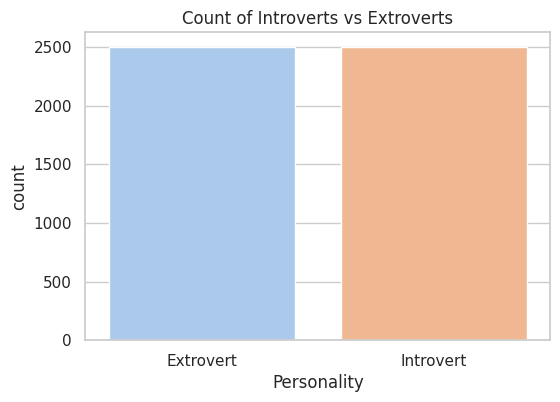

In [76]:
# Print the text output using the correct column name 'Personality'
print(df['Personality'].value_counts())

# Add a visual illustration of the class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Personality', palette='pastel')
plt.title('Count of Introverts vs Extroverts')
plt.show()

Use a histogram to display the number of followers for each samples
 - The x axis should be the number of followers/friends
 - The y axis should be the number of samples in the dataset

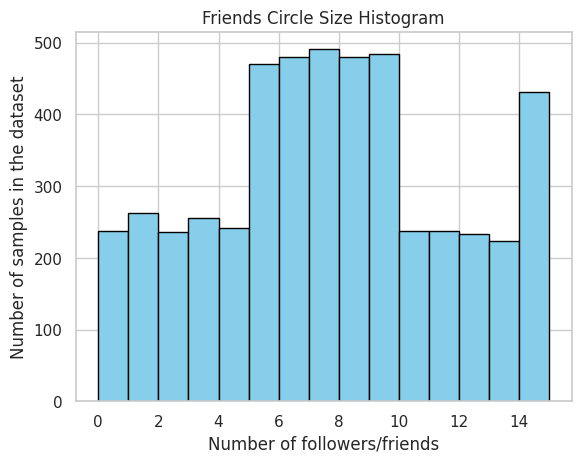

In [78]:
# Using the correct column name 'Friends_circle_size' from your dataset
plt.hist(df['Friends_circle_size'], bins=15, color='skyblue', edgecolor='black')

plt.xlabel('Number of followers/friends')
plt.ylabel('Number of samples in the dataset')
plt.title('Friends Circle Size Histogram')
plt.show()

Remove the name column using `drop()` method

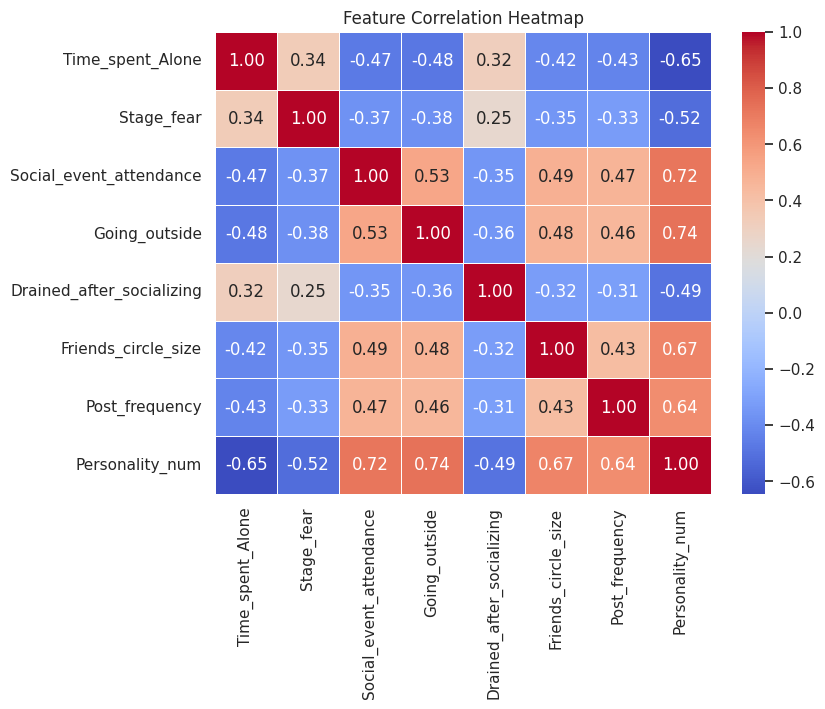

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality,Personality_num
0,3,1,6,7,0,14,5,Extrovert,1
1,2,0,8,6,0,7,8,Extrovert,1
2,1,0,9,4,0,9,3,Extrovert,1
3,8,0,0,0,1,9,3,Introvert,0
4,5,1,3,0,0,2,6,Introvert,0


In [80]:
# The dataset does not have a 'Name' column, but we need to encode categorical features for KNN
# Mapping categorical columns to numerical values
df['Stage_fear'] = df['Stage_fear'].map({'Yes': 1, 'No': 0})
df['Drained_after_socializing'] = df['Drained_after_socializing'].map({'Yes': 1, 'No': 0})
df['Personality_num'] = df['Personality'].map({'Extrovert': 1, 'Introvert': 0})

# Bonus Illustration: A correlation heatmap to see how features relate to each other
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=['int64', 'float64']).corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

df.head()

## C. Split the dataset into training and test set

Convert the features into an numpy array using `.values()` and store it in a variable "X"

In [81]:
# Define features (X) and target (y)
# We drop the original string 'Personality' and the encoded 'Personality_num' from X
X = df.drop(columns=['Personality', 'Personality_num']).values

Convert the labels into an numpy array using `.values()` and store it in a variable "y"

In [82]:
# Convert the labels into a numpy array using the encoded numerical column
y = df['Personality_num'].values

Use `train_test_split()` to split the data.

- Declare a variable `X_train` that will hold the training data
- Declare a variable `X_test` that will hold the test data
- Declare a variable `y_train` that will hold the label of the training data
- Declare a variable `y_test` that will hold the label of the test data


In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Display the dimensions of each variables using `.shape()`

In [54]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4000, 7)
X_test shape: (1000, 7)
y_train shape: (4000,)
y_test shape: (1000,)


## D. Create the model

Use KNN as a classifier by using `KNeighborsClassifier()`

In [55]:
knn = KNeighborsClassifier(n_neighbors=5)

Train the model using the `.fit()`

In [56]:
# Train the model with encoded numerical data
knn.fit(X_train, y_train)

KNeighborsClassifier()

Test the model using the `.predict()`

In [57]:
# Generate predictions
y_pred = knn.predict(X_test)
y_pred

array([1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1,

## E. Evaluate the model

Create a confusion matrix

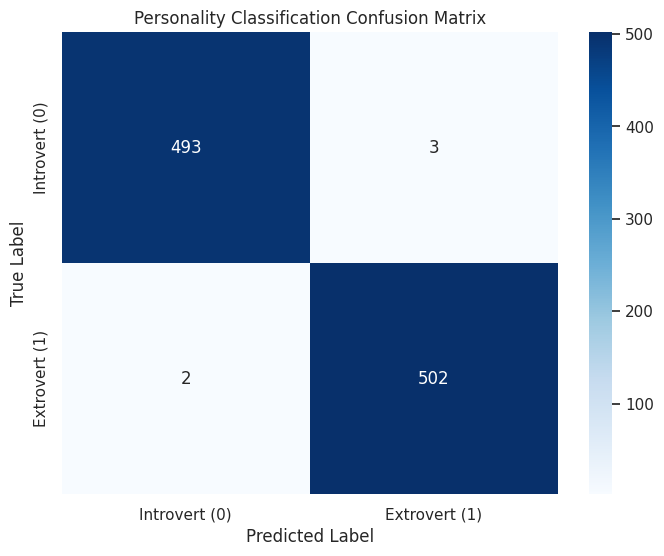

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix using Seaborn for a better illustration
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Introvert (0)', 'Extrovert (1)'],
            yticklabels=['Introvert (0)', 'Extrovert (1)'])

plt.title('Personality Classification Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

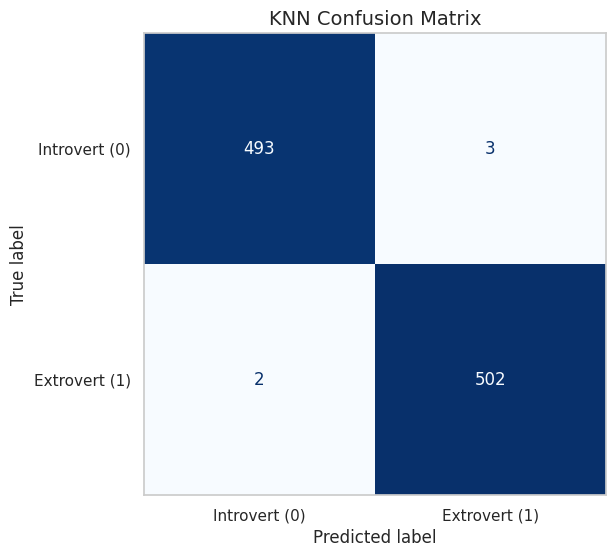

In [58]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Introvert (0)', 'Extrovert (1)'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title("KNN Confusion Matrix", fontsize=14)
plt.grid(False) # Turn off grid lines for a cleaner matrix
plt.show()

Display the accuracy

In [59]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9950


Display the precision

In [60]:
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")

Precision: 0.9941


Display the recall

In [61]:
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")

Recall: 0.9960


Display the f1-score

In [62]:
f1 = f1_score(y_test, y_pred)
print(f'F1-Score: {f1:.4f}')

F1-Score: 0.9950


## F. Predict your own personality

Enter your own features and use the model to generate a prediction using `.predict()`

In [83]:
# The model expects 7 features:
# [Time_spent_Alone, Stage_fear (0/1), Social_event_attendance, Going_outside, Drained_after_socializing (0/1), Friends_circle_size, Post_frequency]

# Example input: Alone=3, Fear=1, Social=6, Outside=7, Drained=0, Friends=14, Post=5
my_features = [[3, 1, 6, 7, 0, 14, 5]]

prediction = knn.predict(my_features)

if prediction[0] == 0:
    print("Prediction: Introvert (0)")
else:
    print("Prediction: Extrovert (1)")

Prediction: Extrovert (1)


# Features: [Time_spent_Alone, Stage_fear (0/1), Social_event_attendance, Going_outside, Drained_after_socializing (0/1), Friends_circle_size, Post_frequency]
my_features = [[3, 1, 6, 7, 0, 14, 5]]

prediction = knn.predict(my_features)

if prediction[0] == 0:
    print('Prediction: Introvert (0)')
else:
    print('Prediction: Extrovert (1)')